# Task Comparison: PSDs and Topomaps

## Overview

You will convert task markers into 15-second epochs, compare condition spectra, and map alpha power. The cells provide structure and API hints, but you must implement the analysis and check each intermediate result.

## Learning objectives

- Standardize task-marker variants without changing their timing.
- Convert annotations into events and exact 15-second epochs.
- Compute and compare Welch PSDs.
- Summarize 8–12 Hz alpha activity for each EEG channel.
- Make comparable condition and difference topomaps.

## Scientific background: eyes-closed alpha

Alpha is an approximately 8–12 Hz rhythm often strongest over posterior scalp during quiet wakefulness. Closing the eyes commonly increases posterior alpha power. This is an expected tendency, not a guaranteed individual result. Drowsiness, muscle artifacts, reference choice, marker errors, and electrode layout can alter the pattern.

In [ ]:
# Setup cell: run this as provided.
from pathlib import Path
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

mne.set_log_level("WARNING")

## Step 1: Load preprocessed EEG

Load the FIF file with preload enabled. Print duration, sampling rate, EEG channel count, bad channels, and annotation count. Confirm that these values agree with earlier notebooks before analyzing conditions.

In [14]:
PREPROCESSED_PATH = Path("../outputs/raw_preprocessed.fif")

# Load the preprocessed Raw object into memory.
import mne

raw = mne.io.read_raw_fif(PREPROCESSED_PATH, preload=True)

# Print the requested quality-control information.
print(raw)
print(f"Duration: {raw.times[-1]:.2f} s")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"EEG channels: {len(mne.pick_types(raw.info, eeg=True))}")
print(f"Bad channels: {raw.info['bads']}")
print(f"Annotations: {len(raw.annotations)}")

Opening raw data file ..\outputs\raw_preprocessed.fif...


C:\Users\wpafb\AppData\Local\Temp\ipykernel_6776\233784132.py:6: RuntimeWarning: This filename (..\outputs\raw_preprocessed.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(PREPROCESSED_PATH, preload=True)


    Range : 0 ... 211647 =      0.000 ...   705.490 secs
Ready.
Reading 0 ... 211647  =      0.000 ...   705.490 secs...
<Raw | raw_preprocessed.fif, 24 x 211648 (705.5 s), ~38.8 MiB, data loaded>
Duration: 705.49 s
Sampling rate: 300.0 Hz
EEG channels: 20
Bad channels: []
Annotations: 76


## Step 2: Inspect the existing task annotations

Notebook 1 saved the XDF markers as MNE annotations, and Notebook 2 preserved them. Because the task labels have already been verified, use their original names directly: `Eyes Open` and `Eyes Closed`.

Display the annotation counts once more as a quick check, then define the integer code for each condition. Do not rebuild, rename, or normalize the annotations.

In [17]:
import pandas as pd

# Inspect the labels already attached to the preprocessed Raw object.
annotation_counts = pd.Series(raw.annotations.description).value_counts()
display(annotation_counts)

EYES_OPEN_LABEL = 1
EYES_CLOSED_LABEL = 2

event_id = {
    EYES_OPEN_LABEL: 1,
    EYES_CLOSED_LABEL: 2,
}
print("Event mapping:", event_id)

eyes_open_start      19
eyes_open_end        19
eyes_closed_start    19
eyes_closed_end      19
Name: count, dtype: int64

Event mapping: {1: 1, 2: 2}


In [19]:
# Convert the two existing annotation names directly into MNE events.
events, returned_event_id = mne.events_from_annotations(
    raw,
    event_id={'eyes_open_start': 1, 'eyes_closed_start': 2},
)

print("MNE returned event mapping:", returned_event_id)

Used Annotations descriptions: [np.str_('eyes_closed_start'), np.str_('eyes_open_start')]
MNE returned event mapping: {np.str_('eyes_closed_start'): 2, np.str_('eyes_open_start'): 1}


## Step 3: Check the event counts

Count the events created in Step 2. The expected design has 20 `Eyes Open` and 20 `Eyes Closed` trials. Do not silently continue if counts differ; investigate missing or extra markers first.

In [20]:
# TODO: count events for each condition and compare with 20 each.
event_counts = {
    condition: (events[:, 2] == event_code).sum()
    for condition, event_code in event_id.items()
}
print(event_counts)

{1: np.int64(19), 2: np.int64(19)}


## Step 4: Create eyes-open and eyes-closed epochs

Create epochs beginning at each marker. To obtain exactly 15 seconds of samples, use `tmin=0` and `tmax=15 - 1/sfreq`. Set `baseline=None`, select EEG channels, preload, and reject segments overlapped by BAD annotations. Print retained counts and inspect `epochs.drop_log`.

In [22]:
TRIAL_DURATION = 15.0

# TODO: calculate an inclusive MNE tmax for exactly 15 seconds.
sfreq = raw.info["sfreq"]

tmax =  15 - 1 / sfreq

# TODO: create the epochs with the parameters described above.
epochs = mne.Epochs(
    raw,
    events,
    event_id={"eyes_open_start": 1, "eyes_closed_start": 2},
    tmin=0,
    tmax=tmax,
    baseline=None,
    picks="eeg",
    preload=True,
    reject_by_annotation=True,
)

# TODO: print retained counts for both conditions.
print(epochs)
print(epochs.event_id)
print("Epoch counts:", {k: len(epochs[k]) for k in epochs.event_id})

# Inspect dropped epochs.
print("Drop log:")
print(epochs.drop_log)

Not setting metadata
38 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 38 events and 4500 original time points ...
0 bad epochs dropped
<Epochs | 38 events (all good), 0 – 14.997 s (baseline off), ~26.1 MiB, data loaded,
 'eyes_open_start': 19
 'eyes_closed_start': 19>
{'eyes_open_start': 1, 'eyes_closed_start': 2}
Epoch counts: {'eyes_open_start': 19, 'eyes_closed_start': 19}
Drop log:
((), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), ())


## Step 5: Plot example epochs

Plot three eyes-open and three eyes-closed epochs using MNE condition selection (`epochs['condition']`). Inspect whether one large artifact could dominate a condition average. Record any trial exclusions using a rule that does not depend on condition.

Using matplotlib as 2D backend.


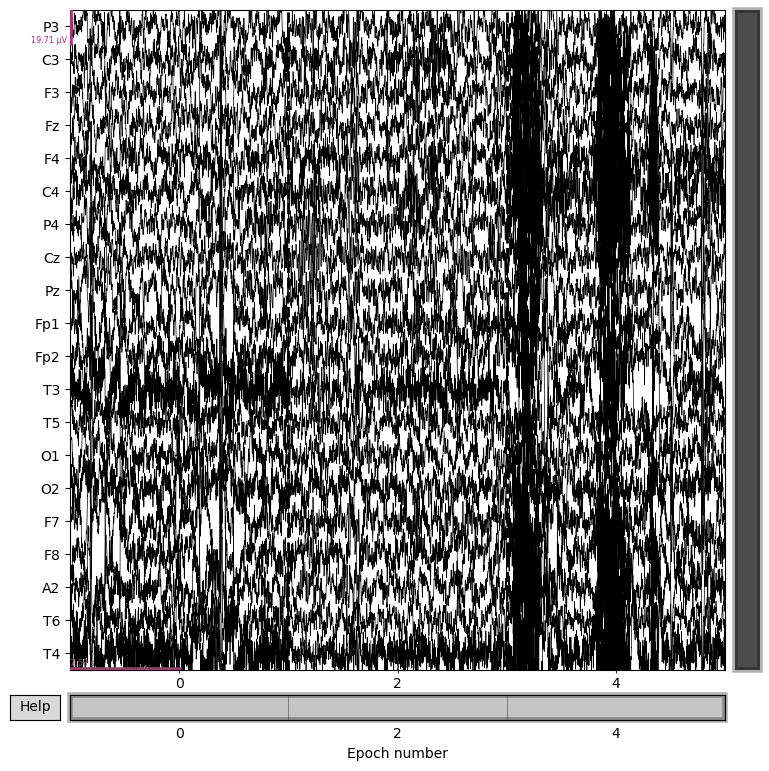

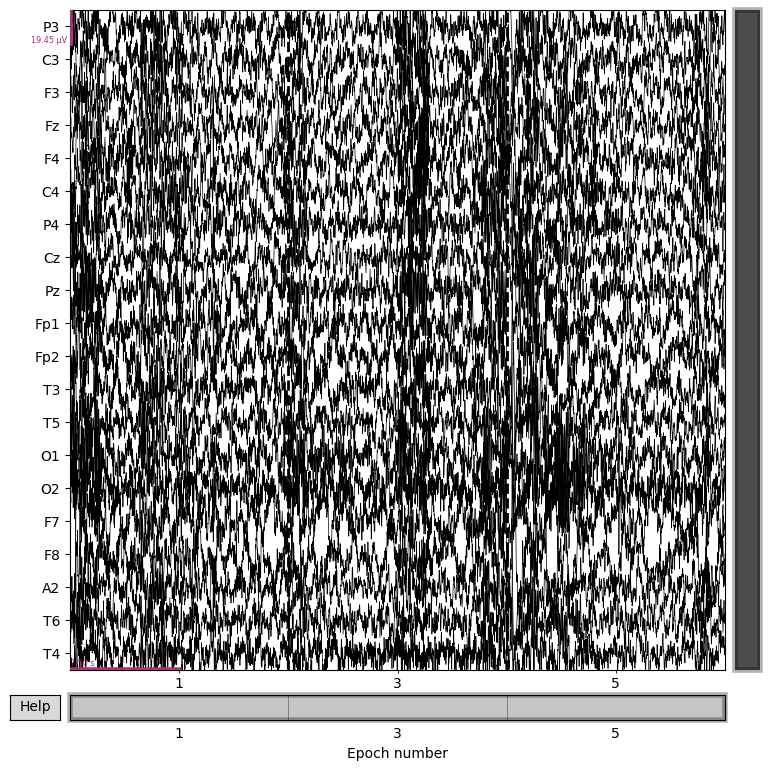

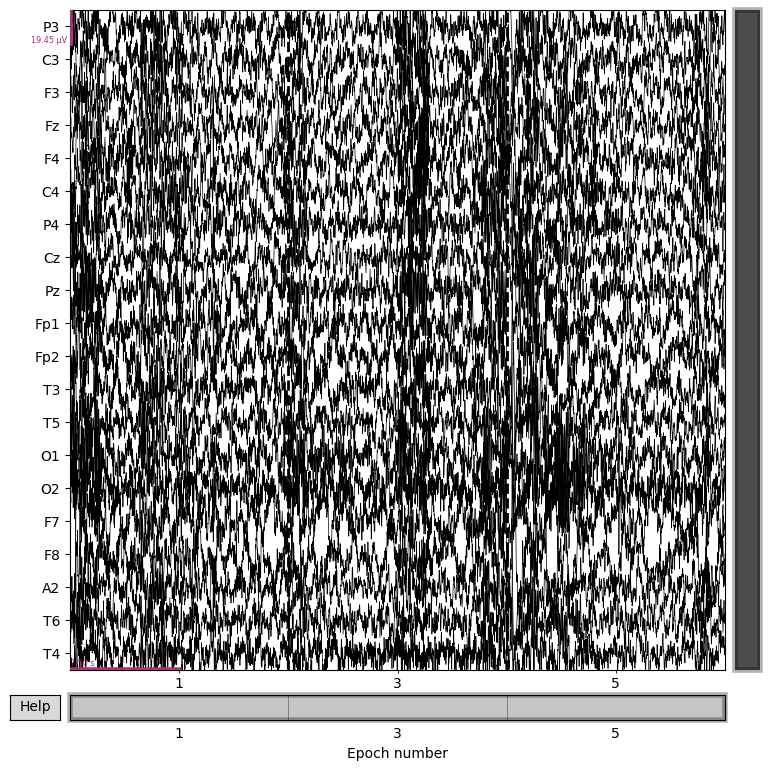

In [24]:
# TODO: select and plot up to three epochs from each condition.
# TODO: select and plot up to three epochs from each condition.
epochs["eyes_open_start"][:3].plot(scalings="auto")
epochs["eyes_closed_start"][:3].plot(scalings="auto")

## Step 6: Compare PSDs

MNE can calculate and plot the power spectral density (PSD) for us. Use `epochs[condition].compute_psd(method='welch', fmin=1, fmax=40)` for each condition, then call the spectrum's `.plot(average=True)` method. MNE handles the Welch settings, averaging, units, and display scaling.

Make two plots side by side with a shared y-axis. Look for a larger bump near 8–12 Hz in the eyes-closed plot. Keeping the same frequency range and shared y-axis makes the comparison fair.

In [26]:
# TODO: compute a 1–40 Hz spectrum for each condition.
psd_open = epochs["eyes_open_start"].compute_psd(method="welch", fmin=1, fmax=40)
psd_closed = epochs["eyes_closed_start"].compute_psd(method="welch", fmin=1, fmax=40)

# TODO: let MNE plot the average EEG spectrum for each condition.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
psd_open.plot(average=True, picks="eeg", axes=axes[0], show=False)
psd_closed.plot(average=True, picks="eeg", axes=axes[1], show=False)
axes[0].set_title("Eyes open")
axes[1].set_title("Eyes closed")
plt.tight_layout()

Effective window size : 6.827 (s)
Effective window size : 6.827 (s)
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


## Step 7: Compute alpha-band power

A PSD contains many frequency values for every channel. A topomap needs just **one number per channel**, so we need a simple alpha summary.

Compute a second spectrum restricted to 8–12 Hz. `get_data()` has the shape trials × channels × frequencies. Taking the mean across trials (axis 0) and frequencies (axis 2) leaves one mean alpha PSD value per channel. Multiplying by `1e12` converts V²/Hz to the more readable µV²/Hz.

This tutorial uses the mean PSD within the alpha range. Integrating the curve would estimate total alpha-band power, but that additional numerical concept is not needed to compare conditions here.

In [33]:
# TODO: compute spectra containing only the 8–12 Hz alpha range.
alpha_psd_open = epochs["eyes_open_start"].compute_psd(method="welch", fmin=8, fmax=12)
alpha_psd_closed = epochs["eyes_closed_start"].compute_psd(method="welch", fmin=8, fmax=12)



alpha_table = pd.DataFrame(
    {
        "eyes_open": alpha_open_mean,
        "eyes_closed": alpha_closed_mean,
        "closed_minus_open": alpha_difference,
    },
    index=epochs.ch_names,
)

display(alpha_table.sort_values("closed_minus_open", ascending=False))
alpha_psd_closed = epochs["eyes_closed_start"].compute_psd(method="welch", fmin=8, fmax=12)

# TODO: average over trials and frequency bins, leaving one value per channel.
# The factor 1e12 converts V²/Hz to µV²/Hz.


alpha_open_mean = alpha_psd_open.get_data().mean(axis=(0, 2)) * 1e12
alpha_closed_mean = alpha_psd_closed.get_data().mean(axis=(0, 2)) * 1e12
alpha_difference = alpha_closed_mean - alpha_open_mean

alpha_table = pd.DataFrame(
    {
        "eyes_open": alpha_open_mean,
        "eyes_closed": alpha_closed_mean,
        "closed_minus_open": alpha_difference,
    },
    index=epochs.ch_names,
)

Effective window size : 6.827 (s)
Effective window size : 6.827 (s)


,eyes_open,eyes_closed,closed_minus_open
O1,2.408267,5.834448,3.426181
Pz,2.062477,5.052861,2.990384
O2,1.877049,4.329238,2.452190
T6,1.514964,2.126671,0.611707
P4,2.171896,2.676998,0.505102
T5,1.726516,2.021081,0.294565
F3,1.571767,1.807278,0.235512
Fz,1.795945,2.012881,0.216937
T3,1.621093,1.589204,-0.031889
F4,1.984551,1.922829,-0.061722


Effective window size : 6.827 (s)


## Step 8: Plot alpha topomaps

Topomaps need electrode locations. Instead of inspecting coordinate arrays, first call `epochs.plot_sensors(show_names=True)`. You should see the channel names arranged sensibly around a head. If MNE reports missing locations—or channels appear piled together—return to Notebook 2 and set the correct montage.

Once the sensor plot looks correct, use the spectrum object's built-in `.plot_topomap()` method. Pass an alpha band dictionary such as `{'Alpha (8–12 Hz)': (8, 12)}`. MNE will average the alpha frequencies and draw the scalp map. Make one map for each condition and read each colorbar before comparing colors.

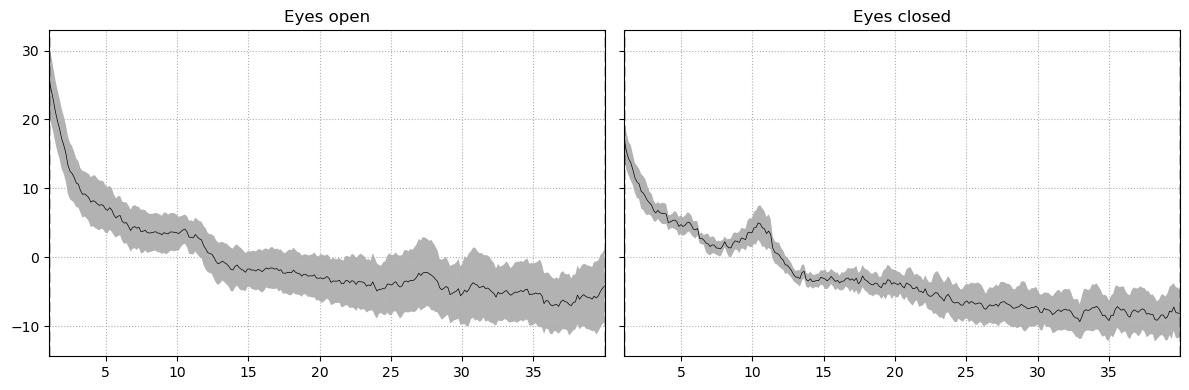

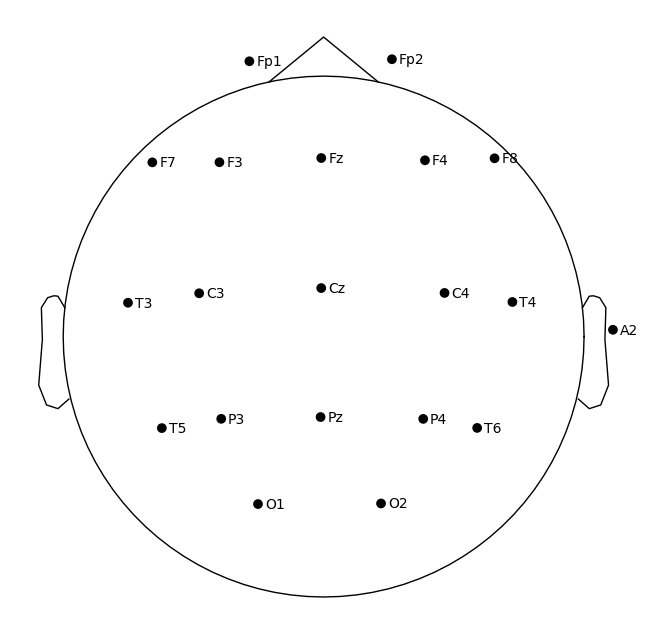

Averaging across epochs before plotting...


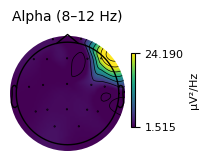

Averaging across epochs before plotting...


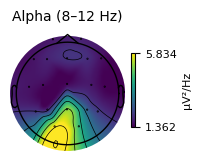

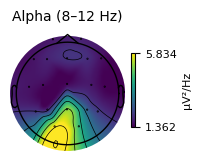

In [34]:
# Visual check: do the sensor labels appear in sensible locations on the head?
epochs.plot_sensors(show_names=True)

alpha_band = {"Alpha (8–12 Hz)": (8, 12)}

# TODO: use MNE's built-in topomap method for each alpha spectrum.
alpha_psd_open.plot_topomap(
    bands=alpha_band, ch_type="eeg", cmap="viridis"
)
alpha_psd_closed.plot_topomap(
    bands=alpha_band, ch_type="eeg", cmap="viridis"
)

## Step 9: Plot eyes-closed minus eyes-open alpha difference

The two condition maps may use different automatic color scales, so the clearest direct comparison is a difference map. Subtract eyes-open from eyes-closed mean alpha PSD for every channel.

Use `mne.viz.plot_topomap` with a red–blue color map. Set equal negative and positive limits using the largest absolute difference so zero is the center: red indicates stronger eyes-closed alpha and blue indicates stronger eyes-open alpha. A posterior red region supports the hypothesis descriptively; it is not a statistical significance test.

In [ ]:
import numpy as np

# TODO: center the color scale on zero using the largest absolute difference.
try:
    difference_limit = np.abs(alpha_difference).max()
except NameError:
    difference_limit = np.abs(alpha_difference).max()
fig, ax = plt.subplots(figsize=(5, 4))
image, _ = mne.viz.plot_topomap(
    alpha_difference, epochs.info, axes=ax, cmap="RdBu_r",
    vlim=(-difference_limit, difference_limit), show=False
)
ax.set_title("Eyes closed − eyes open alpha")
fig.colorbar(image, ax=ax, label="Mean alpha PSD difference (µV²/Hz)")

# TODO: save the epochs for Notebook 4.
EPOCHS_PATH = Path("../outputs/eyes_open_closed_epo.fif")


NameError: name 'np' is not defined

## Student exercises

1. Compare a posterior-channel PSD with a frontal-channel PSD.
2. Repeat the alpha summary with 8–13 Hz and document whether the conclusion changes.
3. Plot trial-level alpha values for the strongest-difference channel and identify outliers without deleting them.

## Reflection questions

- Why might eyes-closed trials increase alpha power?
- Which channels showed the strongest difference? Were they posterior?
- Did a few trials dominate the average?
- What timing or label error could create a misleading condition difference?

## Summary

After completing the TODOs, you will have built condition epochs from real markers, checked trial counts, used MNE's built-in PSD plots, summarized alpha activity, and created condition and difference scalp maps.